In [1]:
import pandas as pd
import numpy as np

from transformers import AutoTokenizer, AutoProcessor, AutoModel
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from torchinfo import summary
from torch import nn

/mnt/d/Student/8th_semester-skripsi/bukan-skripsi/notebooks/1st_exp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Get dataset
!wget -O dataset.csv "https://drive.google.com/uc?export=download&id=1297LDh5mAAnyZaHEanByfsj_r72syTjK"
!wget

--2026-04-13 14:33:49--  https://drive.google.com/uc?export=download&id=1297LDh5mAAnyZaHEanByfsj_r72syTjK
Resolving drive.google.com (drive.google.com)... 173.194.79.139, 173.194.79.102, 173.194.79.138, ...
Connecting to drive.google.com (drive.google.com)|173.194.79.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1297LDh5mAAnyZaHEanByfsj_r72syTjK&export=download [following]
--2026-04-13 14:33:49--  https://drive.usercontent.google.com/download?id=1297LDh5mAAnyZaHEanByfsj_r72syTjK&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.218.132, 2a00:1450:4013:c08::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.218.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 474443 (463K) [application/octet-stream]
Saving to: ‘dataset.csv’

dataset.csv         100%[===================>] 463.32K  --.-KB/s  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv("./dataset/dataset.csv", encoding="utf-8")

df.head()

,image_id,text_en,text_id,label
0,862902619928506372,i am guessing # netflix no longer lets you gra...,"Menurutku, #Netflix sepertinya nggak lagi meng...",1
1,892551658487631873,it 's the insensitive strikeouts at suntrust p...,Itu adalah strikeout yang mengecewakan di SunT...,1
2,853143461360480256,"following the path of the river calder , so .....","menyusuri aliran Sungai Calder, jadi... suram....",1
3,918423568823840768,# westernsahara # authority has no lessons 2ge...,#sahara barat #pemerintah tidak perlu belajar ...,1
4,731617467718610944,hey <user> great sale !,"Hai <user>, obralnya keren banget!",1


In [3]:
#show some stats
print(df.describe())
print(df.info())

           image_id        label
count  2.373000e+03  2373.000000
mean   8.241311e+17     0.389802
std    5.205076e+16     0.487808
min    6.827168e+17     0.000000
25%    8.193237e+17     0.000000
50%    8.218690e+17     0.000000
75%    8.276195e+17     1.000000
max    9.465246e+17     1.000000
<class 'pandas.DataFrame'>
RangeIndex: 2373 entries, 0 to 2372
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   image_id  2373 non-null   int64
 1   text_en   2373 non-null   str  
 2   text_id   2373 non-null   str  
 3   label     2373 non-null   int64
dtypes: int64(2), str(2)
memory usage: 74.3 KB
None


In [4]:
#check the target distribution
print(df['label'].value_counts())

label
0    1448
1     925
Name: count, dtype: int64


# POC

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
class SimpleSarcasmDataset(Dataset):
    def __init__(self, data, tokenizer, processor):
        self.data = data
        self.tokenizer = tokenizer
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        
        text_inputs = self.tokenizer(item['text_id'], return_tensors="pt", padding='max_length', truncation=True, max_length=128)
        
        image = Image.open(f"./dataset/dataset_image/{item['image_id']}.jpg").convert("RGB")
        image_inputs = self.processor(images=image, return_tensors="pt")
        
        return {
            'input_ids': text_inputs['input_ids'],
            'pixel_values': image_inputs['pixel_values'],
            'label': torch.tensor(item['label'], dtype=torch.float)
        }

In [7]:
#dataset split
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# Get all indices and labels
indices = list(range(len(df)))
labels = df.label

# Split indices (stratify=labels ensures both sets have the same class proportions)
train_indices, val_indices = train_test_split(indices, test_size=0.2, stratify=labels)

# Create virtual subsets using these indices
train_dataset_subset = Subset(df, train_indices)
val_dataset_subset = Subset(df, val_indices)

In [8]:
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p2")

print(f"Max length: {tokenizer.model_max_length}")
print(f"Vocab size: {tokenizer.vocab_size}")

dummy_text = "Contoh teks untuk tokenisasi."
encoded = tokenizer(dummy_text, return_tensors="pt", padding='max_length', truncation=True, max_length=128)
print(encoded)

print(f"Input IDs shape: {encoded['input_ids'].shape}")

Max length: 1000000000000000019884624838656
Vocab size: 30521
{'input_ids': tensor([[    2,   997,  3392,    90, 17461,  1144, 30470,     3,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     

In [9]:
processor = AutoProcessor.from_pretrained("google/vit-base-patch16-224")

# 1. See what the model expects for dimensions
print(f"Expected size: {processor.size}") 

# 2. See normalization values (Mean and Std)
print(f"Mean: {processor.image_mean}")
print(f"Std: {processor.image_std}")

# 3. Check the output shape with a dummy image (e.g., a random tensor)
import torch
dummy_image = torch.randn(3, 500, 500) # Simulating a 500x500 RGB image
pixel_values = processor(dummy_image, return_tensors="pt")["pixel_values"]

print(f"Processed image shape: {pixel_values.shape}")
# Likely [1, 3, 224, 224]

Expected size: SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None)
Mean: (0.5, 0.5, 0.5)
Std: (0.5, 0.5, 0.5)
Processed image shape: torch.Size([1, 3, 224, 224])


In [10]:
train_dataset = DataLoader(SimpleSarcasmDataset(train_dataset_subset.dataset.to_dict(orient='records'), tokenizer, processor), batch_size=16, shuffle=True)
val_dataset = DataLoader(SimpleSarcasmDataset(val_dataset_subset.dataset.to_dict(orient='records'), tokenizer, processor), batch_size=16)

In [11]:
class SarcasmModel(nn.Module):
    def __init__(self, text_model, vision_model):
        super().__init__()
        self.text_encoder = text_model
        self.vision_encoder = vision_model
        
        # Freezing encoders for PoC/Baseline
        for param in self.text_encoder.parameters(): param.requires_grad = False
        for param in self.vision_encoder.parameters(): param.requires_grad = False

        # batch_first=True makes it much more intuitive (matches TF/Keras style)
        self.cross_attention = nn.MultiheadAttention(embed_dim=768, num_heads=8, batch_first=True)
        
        self.norm = nn.LayerNorm(768)
        
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.2), # Added dropout to prevent overfitting on 2k data
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, pixel_values):
        # 1. Feature Extraction (No Gradients for frozen models)
        with torch.no_grad():
            # Text: [Batch, 768]
            t_feat = self.text_encoder(input_ids).pooler_output
            # Vision Patches: [Batch, 196, 768] (removing the CLS token at index 0)
            v_feat = self.vision_encoder(pixel_values).last_hidden_state[:, 1:, :]
        
        # 2. Shape Alignment: Text needs a sequence dimension for MHA
        t_feat = t_feat.unsqueeze(1) # Shape: [B, 1, 768]
        
        # 3. Cross-Attention: Text queries the Image Patches
        # attn_output shape: [B, 1, 768]
        attn_output, attn_weights = self.cross_attention(query=t_feat, 
                                                         key=v_feat, 
                                                         value=v_feat)
        
        # 4. Residual + Norm
        fused = self.norm(t_feat + attn_output)
        
        # 5. Classification
        # We squeeze(1) to go from [B, 1, 768] -> [B, 768]
        logits = self.classifier(fused.squeeze(1))
        
        return logits, attn_weights

In [16]:
text_model = AutoModel.from_pretrained("indobenchmark/indobert-base-p2")
vision_model = AutoModel.from_pretrained("google/vit-base-patch16-224")
model = SarcasmModel(text_model, vision_model).to(device)

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 8369.50it/s]
ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
# Define dummy inputs that match the shapes you found above
batch_size = 16
seq_len = 128 # or tokenizer.model_max_length
img_size = 224

# Create dummy tensors
dummy_input_ids = torch.zeros((batch_size, seq_len), dtype=torch.long).to(device)
dummy_pixel_values = torch.zeros((batch_size, 3, img_size, img_size)).to(device)

# Print the summary
summary(model, input_data=[dummy_input_ids, dummy_pixel_values])

Layer (type:depth-idx)                                  Output Shape              Param #
SarcasmModel                                            [16, 1]                   --
├─BertModel: 1-1                                        [16, 768]                 --
│    └─BertEmbeddings: 2-1                              [16, 128, 768]            --
│    │    └─Embedding: 3-1                              [16, 128, 768]            (38,400,000)
│    │    └─Embedding: 3-2                              [16, 128, 768]            (1,536)
│    │    └─Embedding: 3-3                              [1, 128, 768]             (393,216)
│    │    └─LayerNorm: 3-4                              [16, 128, 768]            (1,536)
│    │    └─Dropout: 3-5                                [16, 128, 768]            --
│    └─BertEncoder: 2-2                                 [16, 128, 768]            --
│    │    └─ModuleList: 3-6                             --                        (85,054,464)
│    └─BertPooler: 2-3 

In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCELoss()

In [18]:
#train
epochs = 20
for t in range(epochs):
    model.train()
    correct = 0
    total = 0
    for item in train_dataset:
        input_ids = item['input_ids'].to(device)
        pixel_values = item['pixel_values'].to(device)
        label = item['label'].to(device)

        # print("Input IDs shape:", input_ids.shape) # [B, 1, 128]
        # print("Pixel values shape:", pixel_values.shape) # [B, 1, 3, 224, 224]
        # print("Label shape:", label.shape) # [B]

        fixed_input_ids = input_ids.squeeze(1)          # [B, 128]
        fixed_pixel_values = pixel_values.squeeze(1)    # [B, 3, 224, 224]
        fixed_label = label.unsqueeze(1)     # [B, 1]

        # print("Fixed Input IDs shape:", fixed_input_ids.shape)
        # print("Fixed Pixel values shape:", fixed_pixel_values.shape)
        # print("Fixed Label shape:", fixed_label.shape)

        output_logits, weights = model(fixed_input_ids, fixed_pixel_values)
        output = torch.sigmoid(output_logits)

        pred = (output > 0.5).float()
        correct += (pred == fixed_label).sum().item()
        total += fixed_label.size(0)
        # print(f"Output: {output.item():.4f}, Label: {label.item():.0f}")
        # print(f"Output[0]: {output[0].item():.4f}, Label[0]: {label[0].item():.0f}")
        loss = criterion(output, fixed_label.view_as(output))
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    epoch_acc = 100 * correct / total

    print(f'Epoch [{t+1}/{epochs}], Correst: {correct}, Total: {total}, Loss: {loss.item():.4f}, Accuracy: {epoch_acc:.2f}%')

Epoch [1/20], Correst: 1603, Total: 2373, Loss: 0.3032, Accuracy: 67.55%
Epoch [2/20], Correst: 1761, Total: 2373, Loss: 0.3283, Accuracy: 74.21%
Epoch [3/20], Correst: 1835, Total: 2373, Loss: 0.6170, Accuracy: 77.33%
Epoch [4/20], Correst: 1931, Total: 2373, Loss: 0.5447, Accuracy: 81.37%
Epoch [5/20], Correst: 2055, Total: 2373, Loss: 0.3970, Accuracy: 86.60%
Epoch [6/20], Correst: 2167, Total: 2373, Loss: 0.1691, Accuracy: 91.32%
Epoch [7/20], Correst: 2235, Total: 2373, Loss: 0.1221, Accuracy: 94.18%
Epoch [8/20], Correst: 2293, Total: 2373, Loss: 0.0206, Accuracy: 96.63%
Epoch [9/20], Correst: 2318, Total: 2373, Loss: 0.0305, Accuracy: 97.68%
Epoch [10/20], Correst: 2299, Total: 2373, Loss: 0.0606, Accuracy: 96.88%
Epoch [11/20], Correst: 2349, Total: 2373, Loss: 0.0014, Accuracy: 98.99%
Epoch [12/20], Correst: 2357, Total: 2373, Loss: 0.0456, Accuracy: 99.33%
Epoch [13/20], Correst: 2356, Total: 2373, Loss: 0.0000, Accuracy: 99.28%
Epoch [14/20], Correst: 2355, Total: 2373, Loss

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

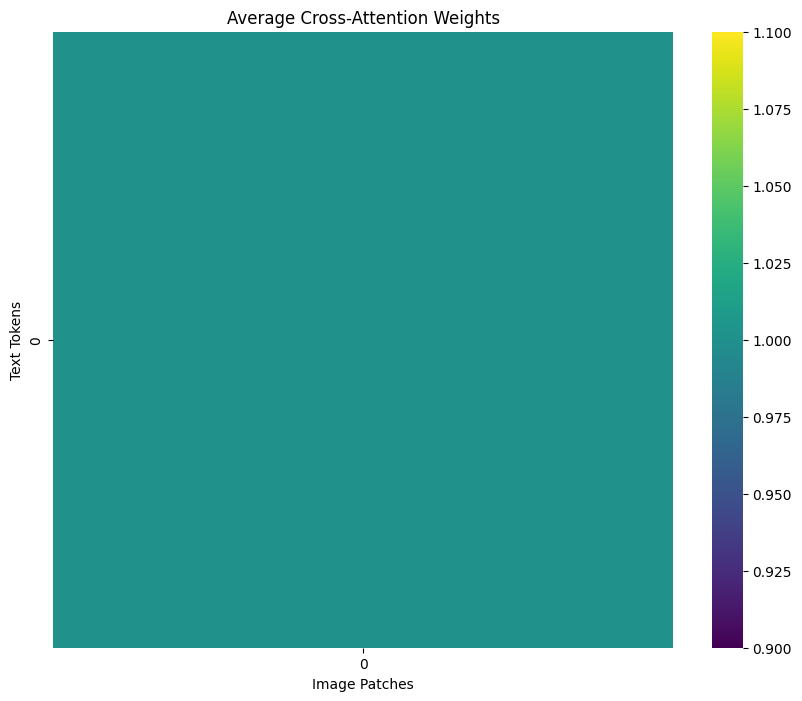

Validation Accuracy: 97.47%


In [22]:
#test
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for item in val_dataset:
        input_ids = item['input_ids'].to(device).unsqueeze(0)
        pixel_values = item['pixel_values'].to(device).unsqueeze(0)
        label = item['label'].to(device).unsqueeze(0)

        # fix shape: DataLoader already returns batched tensors
        input_ids = input_ids.squeeze(0)          # [B, 128]
        pixel_values = pixel_values.squeeze(0)    # [B, 3, 224, 224]
        label = label.squeeze(0).unsqueeze(1)     # [B, 1]

        output_logits, weights = model(input_ids, pixel_values)
        output = torch.sigmoid(output_logits)
        pred = (output > 0.5).float()
        correct += (pred == label).sum().item()
        total += label.size(0)

        # visualize attention map for first image in each batch
        if total <= 16:  # visualize only for the first batch
            attn_weights = weights.cpu().numpy()  # [num_heads, seq_len_text, seq_len_image]
            avg_weights = attn_weights.mean(axis=0)  # Average over heads -> [seq_len_text, seq_len_image]
            plt.figure(figsize=(10, 8))
            sns.heatmap(avg_weights, cmap='viridis')
            plt.title('Average Cross-Attention Weights')
            plt.xlabel('Image Patches')
            plt.ylabel('Text Tokens')
            plt.show()
epoch_acc = 100 * correct / total
print(f'Validation Accuracy: {epoch_acc:.2f}%')

Prediction: 0.0000, Label: 0


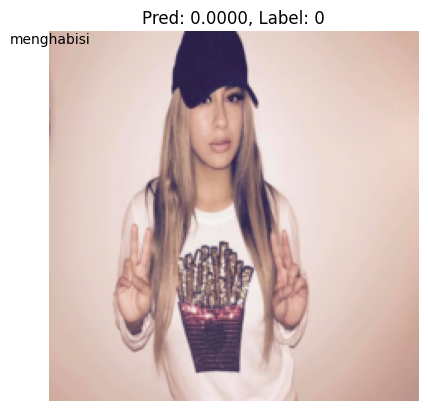

Prediction: 0.0000, Label: 1


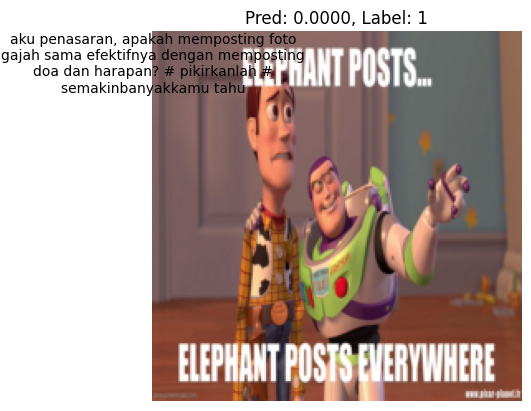

Prediction: 0.0000, Label: 0


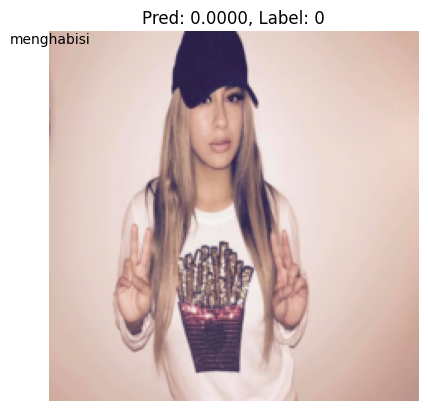

Prediction: 1.0000, Label: 1


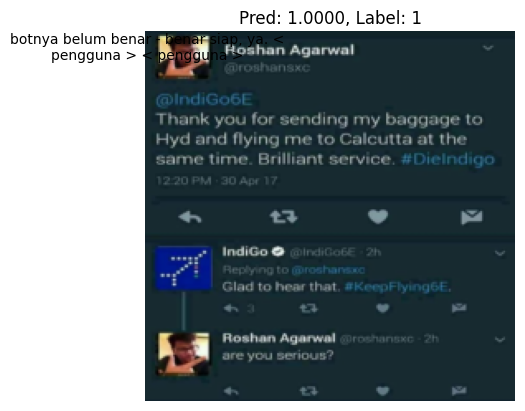

Prediction: 0.0000, Label: 0


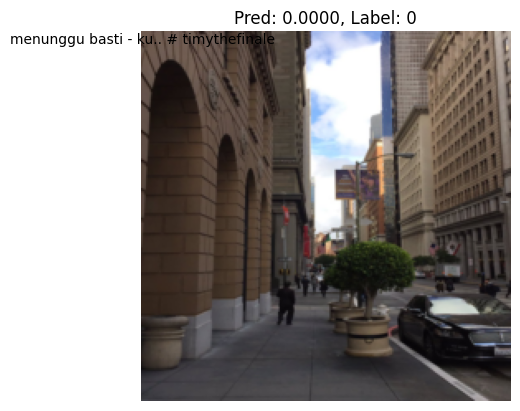

In [96]:
#show 5 random predictions, labels, and the text&image in matplotlib
import matplotlib.pyplot as plt
import random
model.eval()
for _ in range(5):
    item = random.choice(list(val_dataset))
    input_ids = item['input_ids'].to(device).unsqueeze(0)
    pixel_values = item['pixel_values'].to(device).unsqueeze(0)
    label = item['label'].to(device).unsqueeze(0)

    # fix shape: DataLoader already returns batched tensors
    input_ids = input_ids.squeeze(0)          # [B, 128]
    pixel_values = pixel_values.squeeze(0)    # [B, 3, 224, 224]
    label = label.squeeze(0).unsqueeze(1)     # [B, 1]

    output = model(input_ids, pixel_values)
    pred = (output > 0.5).float()

    print(f"Prediction: {pred[0].item():.4f}, Label: {label[0].item():.0f}")

    # Show image
    # pick one image from the batch: [B, 3, 224, 224] -> [3, 224, 224] -> [224, 224, 3]
    image_tensor = pixel_values[0].detach().cpu().permute(1, 2, 0)
    # denormalize (ViT processor uses mean=0.5, std=0.5)
    image_tensor = (image_tensor * 0.5 + 0.5).clamp(0, 1)
    plt.imshow(image_tensor)
    plt.title(f"Pred: {pred[0].item():.4f}, Label: {label[0].item():.0f}")
    # show the text as well
    text = tokenizer.decode(input_ids[0], skip_special_tokens=True)
    plt.text(0.5, -0.1, text, ha='center', va='top', wrap=True)
    plt.axis('off')
    plt.show()

In [77]:
# try to do some inference from external data
image = Image.open("./images.jpeg").convert("RGB")
image_inputs = processor(images=image, return_tensors="pt").to(device)
text_inputs = tokenizer("Wah kamarnya sangat rapi, kamu pasti sangat rajin membersihkan", return_tensors="pt", padding='max_length', truncation=True, max_length=128).to(device)

model.eval()
with torch.no_grad():
    output = model(text_inputs['input_ids'], image_inputs['pixel_values'])
    print(f"Inference Output: {output.item():.4f}")
    pred = (output > 0.5).float()
    print(f"Inference Prediction: {'Sarcastic' if pred.item() == 1 else 'Not Sarcastic'}")

Inference Output: 0.2852
Inference Prediction: Not Sarcastic
